# Datasets with Native Token Counts

One cell per dataset to load it for comparison. Run `download_traces.py` first so the subfolders below are populated.

In [ ]:
import pandas as pd
from pathlib import Path
from datasets import load_from_disk

BASE_DIR = Path(".")

: 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    context="talk", 
    style="ticks", 
    palette="deep", 
    font="sans-serif",
    color_codes=True,
    font_scale=1.1,
    rc={
        'figure.facecolor': 'white', 
        "font.family": "sans-serif", 
        'axes.labelpad': 12,
        'legend.fontsize':12,
        'lines.markersize': 8, 
        'lines.linewidth': 1.2,
        'lines.linestyle': '--', 
        'lines.marker': 'o', 
        'lines.markersize': 2.5,
        'grid.linestyle': '--'
        })

## **Azure LLM Inference Traces 2023 (Splitwise / ISCA'24)**
Azure provides resources to deploy (a large selection) of LLMs for inference. The dataset contains traces of LLM inference workloads running on Azure in 2023, collected by Vidur.

In [2]:
# load the datasets
azure_2023_dir = BASE_DIR / "azure_2023"
azure_2023_code = pd.read_csv(azure_2023_dir / "AzureLLMInferenceTrace_code.csv")
azure_2023_conv = pd.read_csv(azure_2023_dir / "AzureLLMInferenceTrace_conv.csv")

In [5]:
azure_2023_conv.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2023-11-16 18:15:46.6805900,374,44
1,2023-11-16 18:15:50.9951690,396,109
2,2023-11-16 18:15:51.2224670,879,55
3,2023-11-16 18:15:51.3910170,91,16
4,2023-11-16 18:15:52.5732450,91,16


In [53]:
azure_2023_conv.tail()

,TIMESTAMP,ContextTokens,GeneratedTokens
19361,2023-11-16 19:14:04.1442330,1131,397
19362,2023-11-16 19:14:04.5605040,399,181
19363,2023-11-16 19:14:04.7107790,1120,466
19364,2023-11-16 19:14:07.7408440,1030,434
19365,2023-11-16 19:14:08.4025270,197,183


### Characterize input-output tokens

In [169]:
# show the CCDF of the marginals (input and output tokens) for both datasets

def plot_ccdf(df1, df2, in_tokens="ContextTokens", out_tokens="GeneratedTokens", loglog=True, y_lower=None):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.ecdfplot(
        data=df1,
        x=in_tokens,
        complementary=True,
        ax=axes[0],
        label="Input Tokens"
    )
    sns.ecdfplot(
        data=df1,
        x=out_tokens,
        complementary=True,
        ax=axes[0],
        label="Output Tokens"
    )
    if loglog:
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
    axes[0].set_title("Code Dataset")
    axes[0].set_xlabel("Number of Input Tokens")
    axes[0].set_ylabel("CCDF")
    axes[0].legend()

    sns.ecdfplot(
        data=df2,
        x=in_tokens,
        complementary=True,
        ax=axes[1],
        label="Conversation Dataset"
    )
    sns.ecdfplot(
        data=df2,
        x=out_tokens,
        complementary=True,
        ax=axes[1],
        label="Output Tokens"
    )
    if loglog:
        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
    axes[1].set_title("Conversation Dataset")
    axes[1].set_xlabel("Number of Input Tokens")
    axes[1].set_ylabel("CCDF")
    axes[1].legend()

    x_max = max(df1[in_tokens].max(), df2[in_tokens].max())
    y_max = max(df1[out_tokens].max(), df2[out_tokens].max())

    if loglog:
        lim = (1, 1.05 * max(x_max, y_max))
    else:
        lim = (-0.05 * max(x_max, y_max), 1.05 * max(x_max, y_max))

    # set limits to make plots comparable
    axes[0].set_xlim(lim)
    axes[1].set_xlim(lim)
    if y_lower is not None:
        axes[0].set_ylim(bottom=y_lower)
        axes[1].set_ylim(bottom=y_lower)

    plt.tight_layout()
    plt.show()

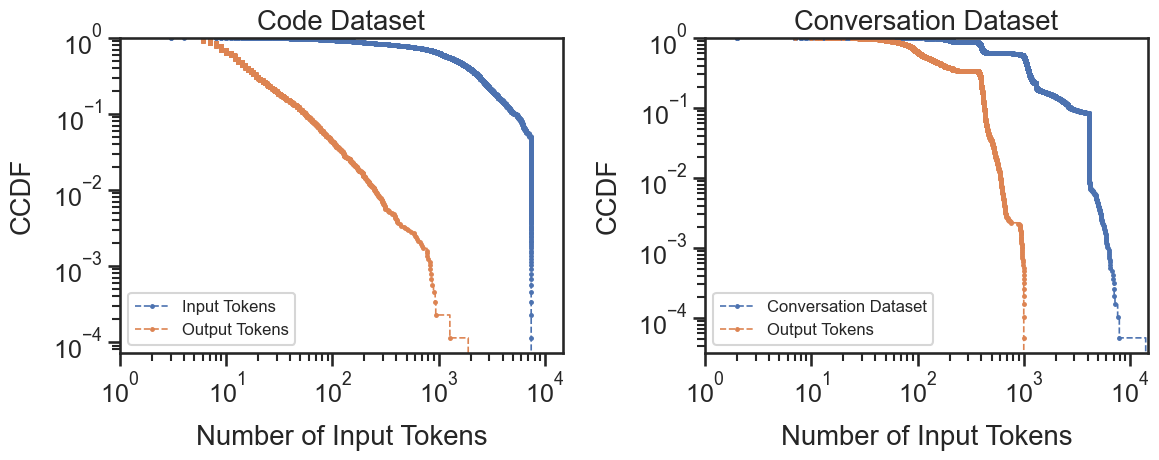

In [93]:
plot_ccdf(azure_2023_code, azure_2023_conv, in_tokens="ContextTokens", out_tokens="GeneratedTokens")

**Q**: *Why the input tokens are so much more than the output tokens?*

The input tokens contain also all the **context** tokens, which can be very large and a re not generated by the model. For example consider the following use cases:

| Workload type               |                             Typical input |             Typical output |
| --------------------------- | ----------------------------------------: | -------------------------: |
| Chat assistant              |        conversation history + new message |                     answer |
| Code completion             |          large code context around cursor |    short code continuation |
| Document summarization      |       long document or retrieved passages |              short summary |
| RAG / search QA             |  system prompt + query + retrieved chunks |      answer with citations |
| Classification / extraction |            long text to classify or parse |              label or JSON |
| Agent/tool workflow         | instructions + prior steps + tool outputs | next action or explanation |

All these case involve a large input context and a much smaller output, which is why the input tokens are much more than the output tokens in the Azure 2023 traces.

In [119]:
def joint_distribution_plot(data, title, kind="kde"):
    """
    Creates a joint distribution plot for the given data.
    It plots also the marginal distributions for the x and y variables.
    Parameters:
    - data: A pandas DataFrame containing the data to plot. It should have columns "ContextTokens" and "GeneratedTokens".
    - title: The title of the plot.
    - kind: The type of joint plot to create. It can be either "hex" for a hexbin plot or "kde" for a kernel density estimate plot.
    Returns:
    - g: The seaborn JointGrid object representing the plot.
    """
    g = sns.JointGrid(
        data=data,
        x="ContextTokens",
        y="GeneratedTokens",
        height=6,
        ratio=5,
        space=0.1
    )

    if kind == "hex":
        g.plot_joint(
            plt.hexbin,
            gridsize=40,
            mincnt=1
        )
    elif kind == "hex_log":
        g.plot_joint(
            plt.hexbin,
            gridsize=40,
            mincnt=1,
            bins="log"
        )
    elif kind == "kde":
        g.plot_joint(
            sns.kdeplot,
            fill=True,
            levels=20,
            thresh=0.05
        )
    else:
        raise ValueError("kind must be either 'hex' or 'kde'")

    g.plot_marginals(
        sns.histplot,
        kde=False,  # if False, only the histogram will be plotted
        bins=40
    )

    g.set_axis_labels("ContextTokens", "GeneratedTokens")
    g.fig.suptitle(title, y=1.02)

    return g

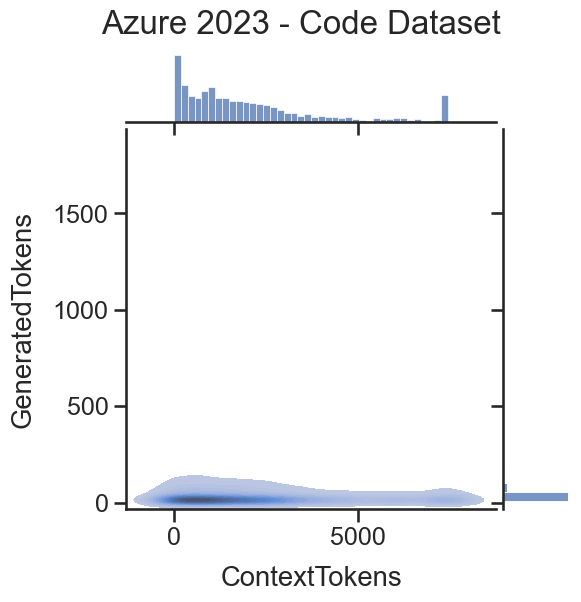

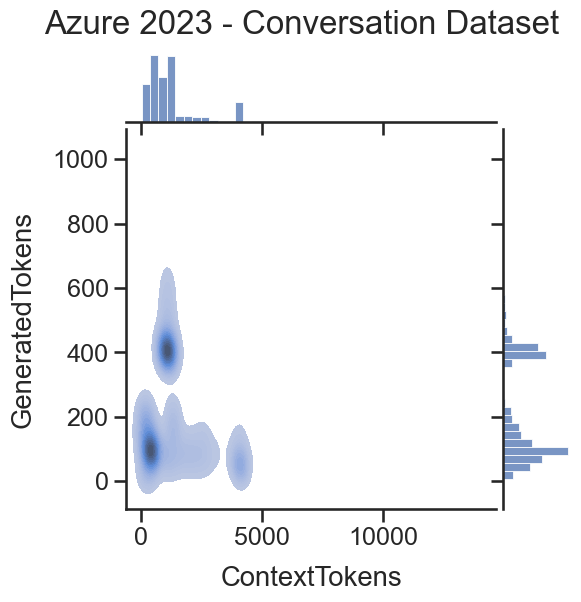

In [ ]:
# distribution of input and output tokens for the code and conversation datasets

EXA = False

kind = "hex" if EXA else "kde"

g1 = joint_distribution_plot(
    azure_2023_code,
    "Azure 2023 - Code Dataset",
    kind=kind
)
plt.show()

g2 = joint_distribution_plot(
    azure_2023_conv,
    "Azure 2023 - Conversation Dataset",
    kind=kind
)
plt.show()

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


def add_joint_panel(
    fig,
    outer_spec,
    data,
    title,
    kind="kde",
    x="ContextTokens",
    y="GeneratedTokens",
    xlim=None,
    ylim=None,
    bins=40,
    gridsize=40,
):
    # Inner layout:
    # top marginal
    # main joint plot + right marginal
    inner = GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer_spec,
        width_ratios=[5, 1],
        height_ratios=[1, 5],
        wspace=0.05,
        hspace=0.05
    )

    ax_marg_x = fig.add_subplot(inner[0, 0])
    ax_joint = fig.add_subplot(inner[1, 0])
    ax_marg_y = fig.add_subplot(inner[1, 1], sharey=ax_joint)

    # ----------------
    # Joint plot
    # ----------------
    if kind == "kde":
        sns.kdeplot(
            data=data,
            x=x,
            y=y,
            ax=ax_joint,
            fill=True,
            levels=20,
            thresh=0.05
        )

    elif kind == "hex":
        hb = ax_joint.hexbin(
            data[x],
            data[y],
            gridsize=gridsize,
            mincnt=1
        )
        fig.colorbar(hb, ax=ax_joint) # , label="count"

    elif kind == "hex_log":
        hb = ax_joint.hexbin(
            data[x],
            data[y],
            gridsize=gridsize,
            mincnt=1,
            bins="log"
        )
        fig.colorbar(hb, ax=ax_joint) # , label="log(count)"

    else:
        raise ValueError("kind must be 'kde', 'hex', or 'hex_log'")

    # ----------------
    # Marginals
    # ----------------
    sns.histplot(
        data=data,
        x=x,
        bins=bins,
        ax=ax_marg_x,
        kde=False
    )

    sns.histplot(
        data=data,
        y=y,
        bins=bins,
        ax=ax_marg_y,
        kde=False
    )

    # ----------------
    # Limits
    # ----------------
    if xlim is not None:
        ax_joint.set_xlim(xlim)
        ax_marg_x.set_xlim(xlim)

    if ylim is not None:
        ax_joint.set_ylim(ylim)
        ax_marg_y.set_ylim(ylim)

    # ----------------
    # Cosmetics
    # ----------------
    ax_joint.set_title(title)
    ax_joint.set_xlabel(x)
    ax_joint.set_ylabel(y)

    ax_marg_x.set_xlabel("")
    ax_marg_x.set_ylabel("")
    ax_marg_y.set_xlabel("")
    ax_marg_y.set_ylabel("")

    ax_marg_x.tick_params(labelbottom=False)
    ax_marg_y.tick_params(labelleft=False)

    sns.despine(ax=ax_marg_x, left=True)
    sns.despine(ax=ax_marg_y, bottom=True)
    sns.despine(ax=ax_joint)

    return ax_joint, ax_marg_x, ax_marg_y

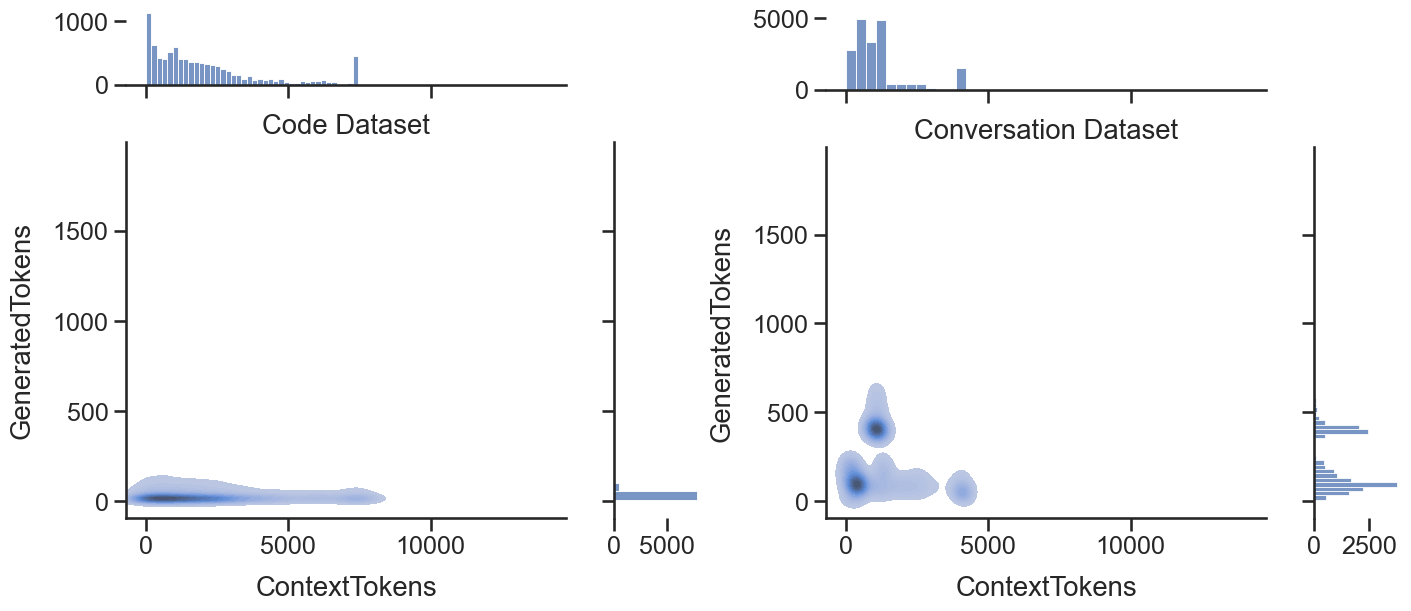

In [24]:
EXA = False

kind = "hex_log" if EXA else "kde"

fig = plt.figure(figsize=(14, 6), constrained_layout=True)

outer = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 1],
    wspace=0.25
)

x_max = max(azure_2023_code["ContextTokens"].max(), azure_2023_conv["ContextTokens"].max())
y_max = max(azure_2023_code["GeneratedTokens"].max(), azure_2023_conv["GeneratedTokens"].max())

xlim = (-0.05 * x_max, 1.05 * x_max)
ylim = (-0.05 * y_max, 1.05 * y_max)

add_joint_panel(
    fig,
    outer[0],
    azure_2023_code,
    title="Code Dataset",
    kind=kind,
    xlim=xlim,
    ylim=ylim
)

add_joint_panel(
    fig,
    outer[1],
    azure_2023_conv,
    title="Conversation Dataset",
    kind=kind,
    xlim=xlim,
    ylim=ylim
)

plt.show()

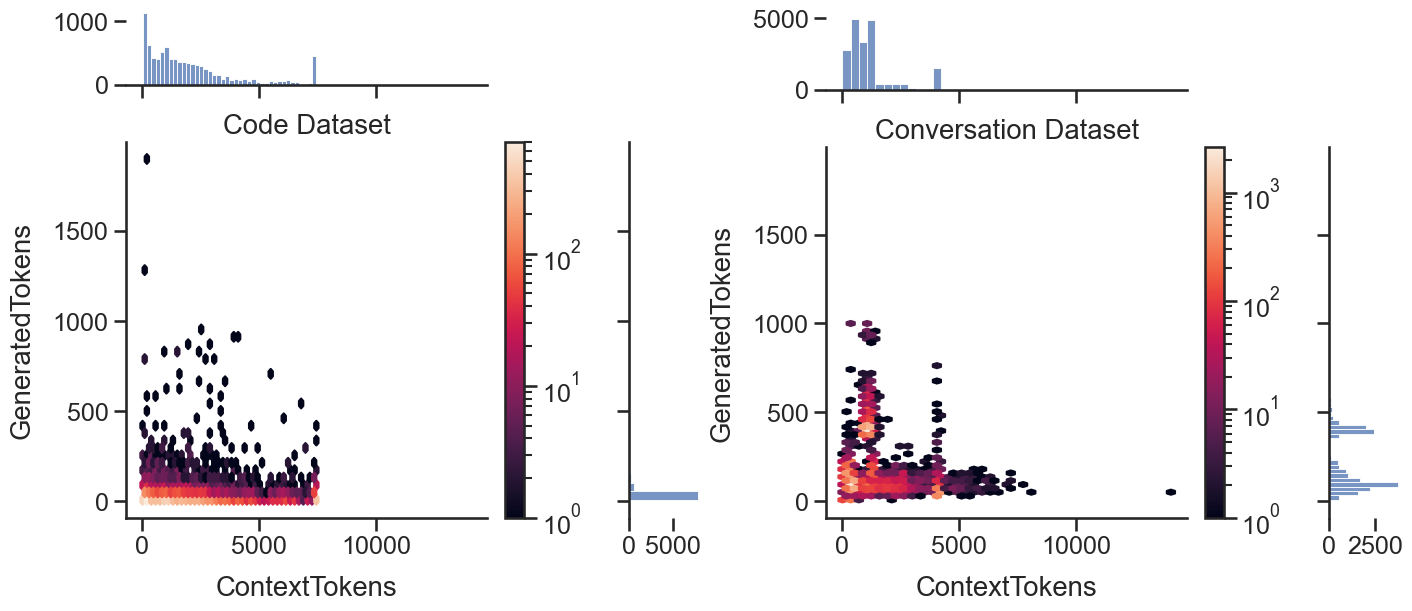

In [27]:
EXA = True

kind = "hex_log" if EXA else "kde"

fig = plt.figure(figsize=(14, 6), constrained_layout=True)

outer = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 1],
    wspace=0.25
)

x_max = max(azure_2023_code["ContextTokens"].max(), azure_2023_conv["ContextTokens"].max())
y_max = max(azure_2023_code["GeneratedTokens"].max(), azure_2023_conv["GeneratedTokens"].max())

xlim = (-0.05 * x_max, 1.05 * x_max)
ylim = (-0.05 * y_max, 1.05 * y_max)

add_joint_panel(
    fig,
    outer[0],
    azure_2023_code,
    title="Code Dataset",
    kind=kind,
    xlim=xlim,
    ylim=ylim
)

add_joint_panel(
    fig,
    outer[1],
    azure_2023_conv,
    title="Conversation Dataset",
    kind=kind,
    xlim=xlim,
    ylim=ylim
)

plt.show()

#

### Characterize the job arrival process

In [202]:
# arrivals over time
def arrival_count_over_time(df, timestamp_col="Timestamp", resample_sec=30, start_date="2023-01-01", timezone="UTC", add_title_suffix=""):

    df = df.copy()

    # If timestamp is numeric, treat it as seconds from an arbitrary day 0
    if pd.api.types.is_numeric_dtype(df[timestamp_col]):
        start = pd.Timestamp(start_date, tz=timezone).normalize()
        df["Timestamp"] = start + pd.to_timedelta(df[timestamp_col], unit="s")
    else:
        df["Timestamp"] = pd.to_datetime(df[timestamp_col], format="mixed", utc=True)

    df = df.sort_values("Timestamp")

    counts = (
        df.set_index("Timestamp")
          .resample(f"{resample_sec}s")
          .size()
    )

    fig, ax = plt.subplots(figsize=(12, 4))

    counts.plot(ax=ax, marker="")

    ax.set_title("Arrival count over time " + add_title_suffix)
    ax.set_xlabel("Time")
    ax.set_ylabel("Number of arrivals every {} s".format(resample_sec))

    plt.show()

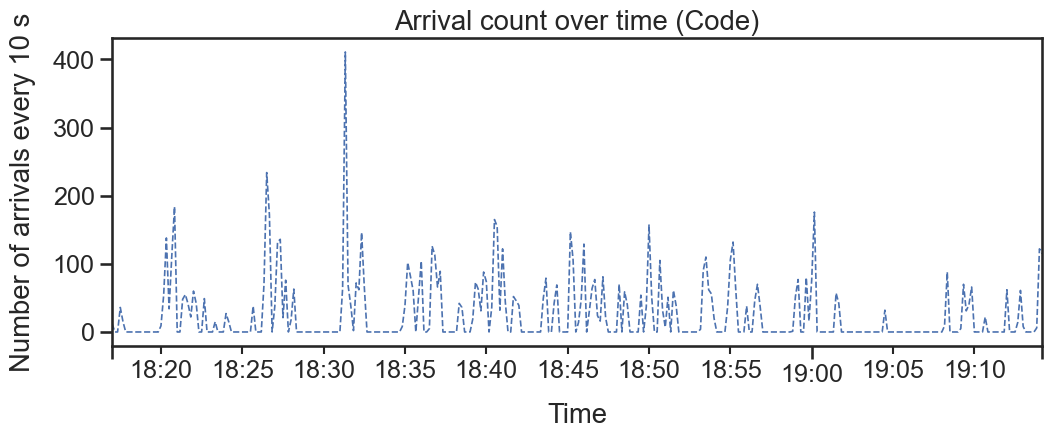

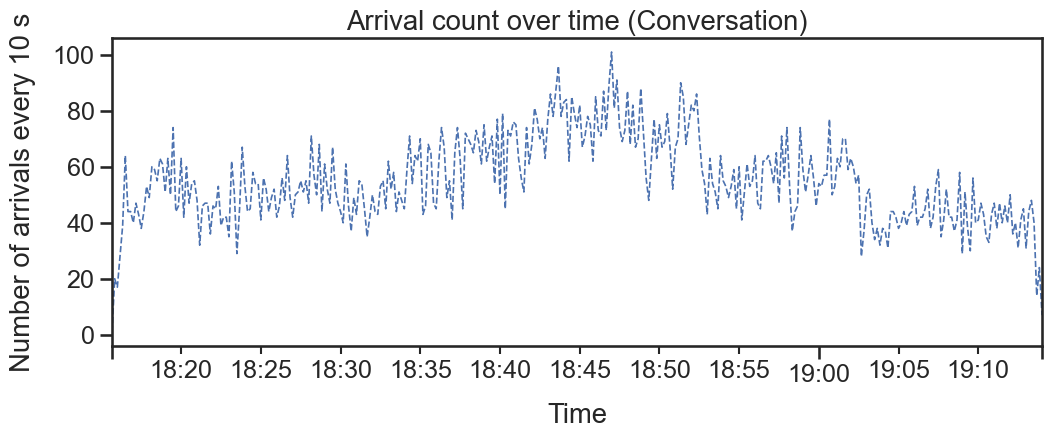

In [171]:
arrival_count_over_time(azure_2023_code, timestamp_col="TIMESTAMP", resample_sec=10, add_title_suffix="(Code)")
arrival_count_over_time(azure_2023_conv, timestamp_col="TIMESTAMP", resample_sec=10, add_title_suffix="(Conversation)")

In [203]:
# Poisson check
def poisson_check(df, timestamp_col="Timestamp", window_sec=30, start_date="2023-01-01", timezone="UTC"):

    df = df.copy()

    # If timestamp is numeric, treat it as seconds from an arbitrary day 0
    if pd.api.types.is_numeric_dtype(df[timestamp_col]):
        start = pd.Timestamp(start_date, tz=timezone).normalize()
        df["Timestamp"] = start + pd.to_timedelta(df[timestamp_col], unit="s")
    else:
        df["Timestamp"] = pd.to_datetime(df[timestamp_col], format="mixed", utc=True)

    df = df.sort_values("Timestamp")

    counts = (
        df.set_index("Timestamp")
        .resample(f"{window_sec}s")
        .size()
    )

    mean_count = counts.mean()
    var_count = counts.var()
    fano_factor = var_count / mean_count  # index of dispersion on counts over windows (should be ~1 for Poisson)

    print("Mean count:", mean_count)
    print("Variance count:", var_count)
    print("Fano factor:", fano_factor)

In [180]:
print("Poisson check for Code Dataset:")
poisson_check(azure_2023_code, timestamp_col="TIMESTAMP", window_sec=10)
print("\nPoisson check for Conversation Dataset:")
poisson_check(azure_2023_conv, timestamp_col="TIMESTAMP", window_sec=10)

Poisson check for Code Dataset:
Mean count: 25.636627906976745
Variance count: 2121.374864397586
Fano factor: 82.74781192343458

Poisson check for Conversation Dataset:
Mean count: 55.173789173789174
Variance count: 234.06971102971102
Fano factor: 4.242407754385447


It was clear also from the simple count plot, here we have a more quantitative view telling us that the code trace is very non-Poisson, while the conversation trace is closer to Poisson but still not quite there.

In [78]:
# inter-arrival time distribution (vs exponential interarrival with same mean)
import numpy as np

def interarrival_time_distribution(df, timestamp_col="Timestamp", add_title_suffix=""):
    df["Timestamp"] = pd.to_datetime(df[timestamp_col])
    df = df.sort_values("Timestamp")

    inter_arrival_times = df["Timestamp"].diff().dropna().dt.total_seconds()

    fig, ax = plt.subplots(figsize=(6.5, 4))

    sns.histplot(inter_arrival_times, bins=50, kde=True, ax=ax)

    mean_inter_arrival = inter_arrival_times.mean()
    x_exp = np.linspace(0, inter_arrival_times.max(), 100)
    y_exp = (1 / mean_inter_arrival) * np.exp(-x_exp / mean_inter_arrival)
    ax.plot(x_exp, y_exp * len(inter_arrival_times) * (inter_arrival_times.max() / 50), label="Exponential Fit", color="red")

    ax.set_title("Inter-arrival Time Distribution " + add_title_suffix)
    ax.set_xlabel("Inter-arrival Time (seconds)")
    ax.set_ylabel("Count")
    ax.legend()

    plt.show()

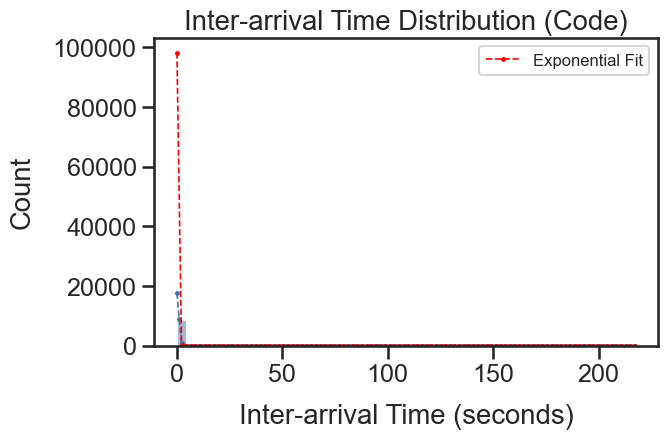

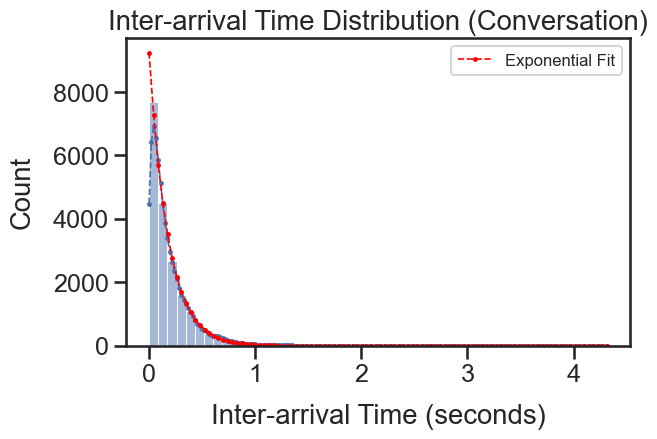

In [79]:
interarrival_time_distribution(azure_2023_code, timestamp_col="TIMESTAMP", add_title_suffix="(Code)")
interarrival_time_distribution(azure_2023_conv, timestamp_col="TIMESTAMP", add_title_suffix="(Conversation)")

<br><br>

<br><br>

<br><br>

## **Azure LLM Inference Traces 2024 (DynamoLLM / HPCA'25)**

In [96]:
azure_2024_dir = BASE_DIR / "azure_2024"
azure_2024_code = pd.read_csv(azure_2024_dir / "AzureLLMInferenceTrace_code_1week.csv")
azure_2024_conv = pd.read_csv(azure_2024_dir / "AzureLLMInferenceTrace_conv_1week.csv")

azure_2024_code.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-10 00:00:00.009930+00:00,2162,5
1,2024-05-10 00:00:00.017335+00:00,2399,6
2,2024-05-10 00:00:00.022314+00:00,76,15
3,2024-05-10 00:00:00.037845+00:00,2376,1
4,2024-05-10 00:00:00.083890+00:00,7670,8


In [100]:
azure_2024_conv.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-12 00:00:00.001163+00:00,1452,3
1,2024-05-12 00:00:00.041683+00:00,584,3
2,2024-05-12 00:00:00.157988+00:00,862,38
3,2024-05-12 00:00:00.158932+00:00,1569,3
4,2024-05-12 00:00:00.248279+00:00,617,104


In [176]:
def all_analysis(df1, df2, in_tokens="ContextTokens", out_tokens="GeneratedTokens", time_col="TIMESTAMP", joint_kind="hex_log", resample_sec=3600, y_lower=None):
    """
    NOTE: the method assumes the first dataset is the "code" dataset and the second is the "conversation" dataset.
    This considers to have a "code" and a "conversation" dataset as input, and produces the following analyses:
    - CCDF of input and output tokens for both datasets
    - a visualization of the joint distribution of input and output tokens for both datasets, with marginals
    - arrivals over time for both datasets
    - Poisson check for both datasets (mean, variance, and Fano factor of counts over windows)
    """

    # ------------- Input and output token distribution -------------

    # CCDF of input and output tokens for both input datasets
    plot_ccdf(df1, df2, in_tokens=in_tokens, out_tokens=out_tokens, loglog=True, y_lower=y_lower)

    # a visualization of the joint distribution of input and output tokens for both datasets, with marginals
    fig = plt.figure(figsize=(14, 6), constrained_layout=True)

    outer = GridSpec(
        1, 2,
        figure=fig,
        width_ratios=[1, 1],
        wspace=0.25
    )

    x_max = max(df1[in_tokens].max(), df2[in_tokens].max())
    y_max = max(df1[out_tokens].max(), df2[out_tokens].max())

    xlim = (-0.05 * x_max, 1.05 * x_max)
    ylim = (-0.05 * y_max, 1.05 * y_max)

    add_joint_panel(
        fig,
        outer[0],
        df1,
        title="Code Dataset",  # hardcoded, assuming the first is the code dataset
        kind=joint_kind,
        xlim=xlim,
        ylim=ylim,
        x=in_tokens,
        y=out_tokens
    )

    add_joint_panel(
        fig,
        outer[1],
        df2,
        title="Conversation Dataset",
        kind=joint_kind,
        xlim=xlim,
        ylim=ylim,
        x=in_tokens,
        y=out_tokens
    )

    plt.show()


    # ------------- Arrivals information -------------

    # arrivals over time
    arrival_count_over_time(df1, timestamp_col=time_col, resample_sec=resample_sec, add_title_suffix="(Code)")
    arrival_count_over_time(df2, timestamp_col=time_col, resample_sec=resample_sec, add_title_suffix="(Conversation)")

    # Poisson check
    print("Poisson check for Code Dataset:")
    poisson_check(df1, timestamp_col=time_col, window_sec=resample_sec)
    print("\nPoisson check for Conversation Dataset:")
    poisson_check(df2, timestamp_col=time_col, window_sec=resample_sec)

C:\Users\localadmin\AppData\Local\Temp\ipykernel_104436\2451672830.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\localadmin\.venvs\llm-vidur\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


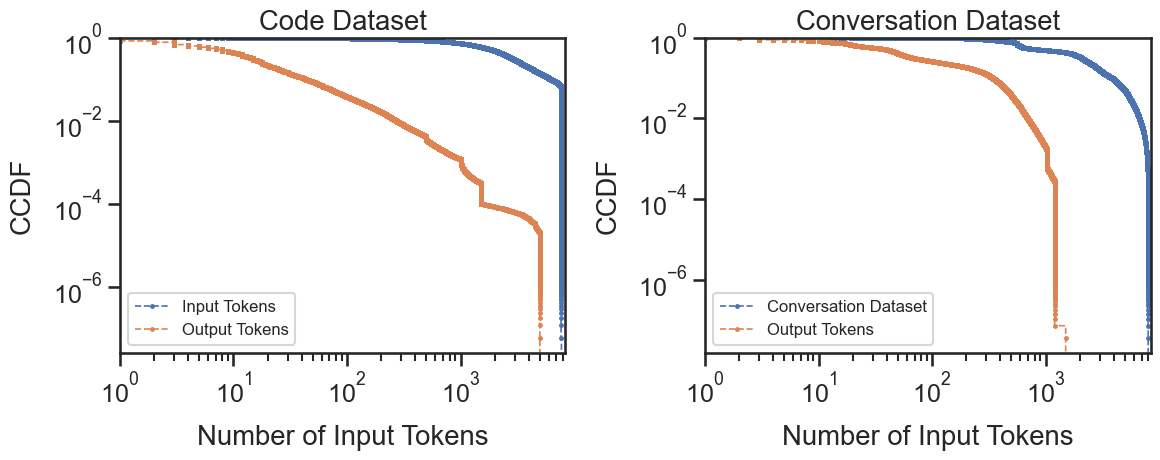

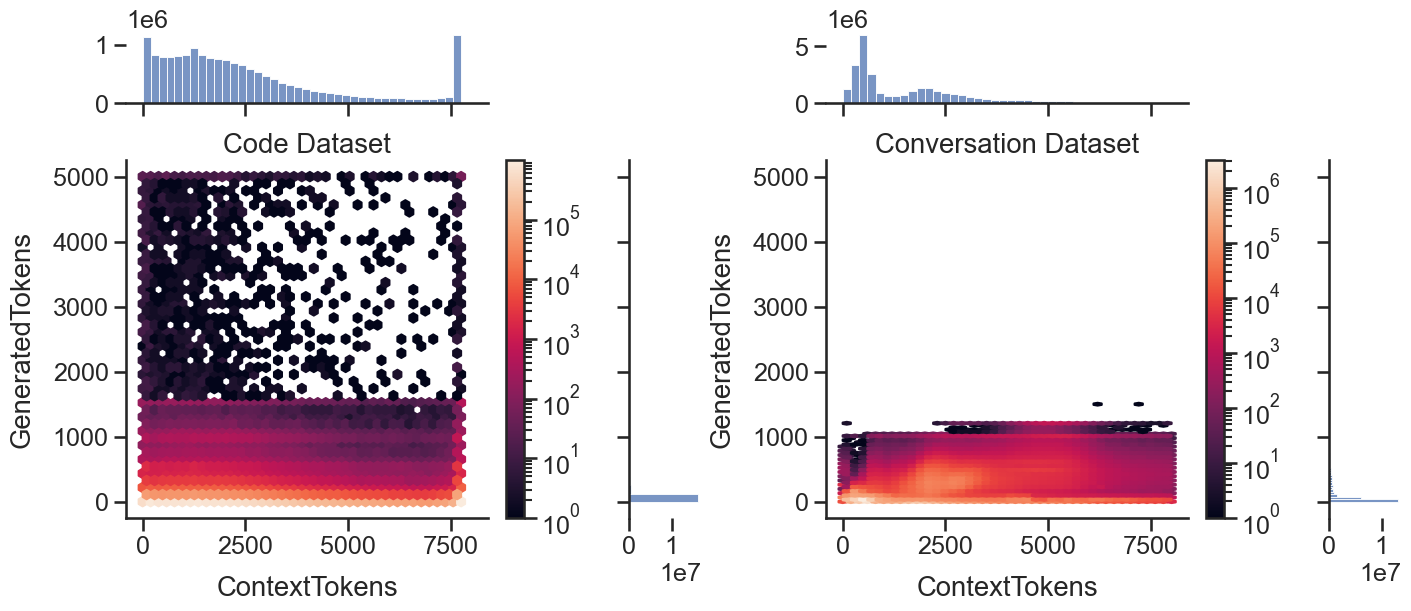

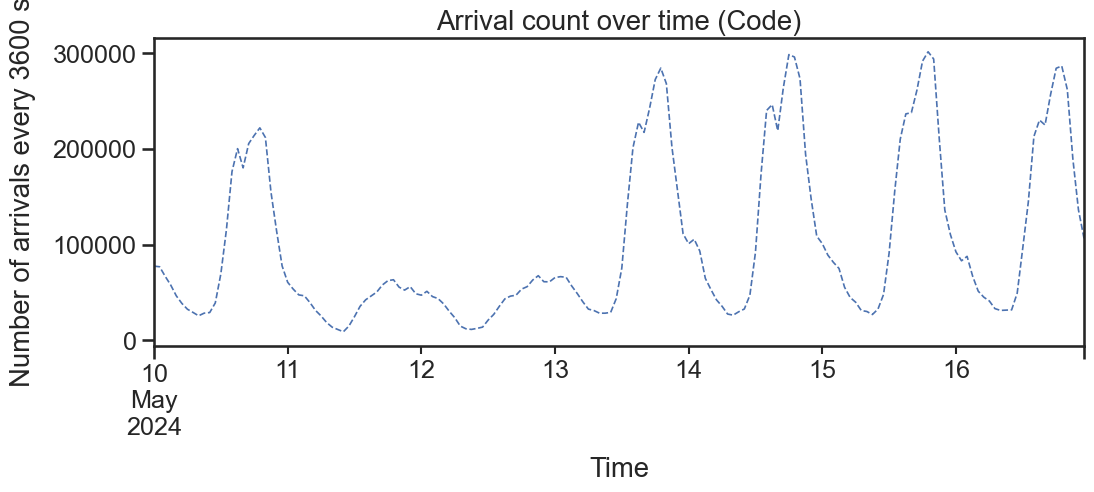

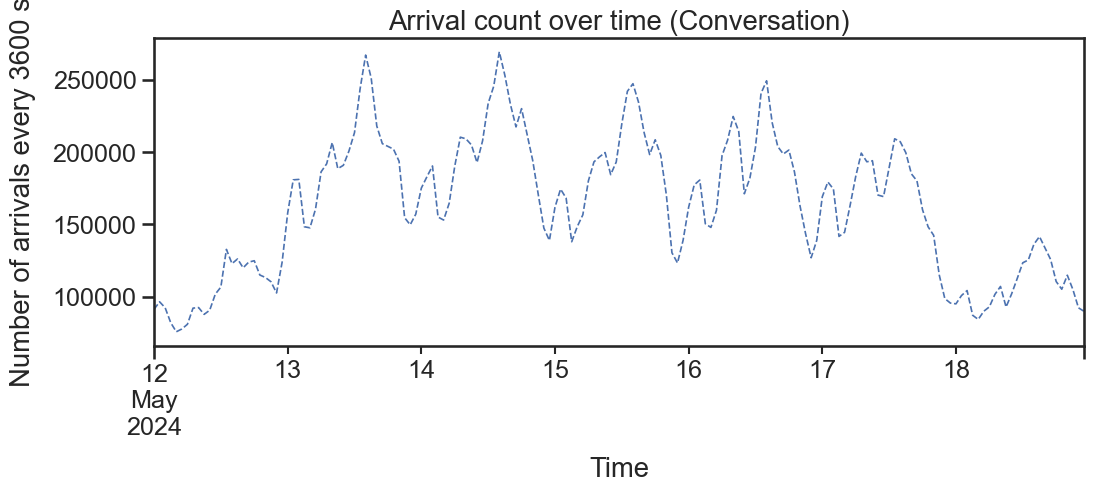

Poisson check for Code Dataset:
Mean count: 100021.99404761905
Variance count: 7188785834.329307
Fano factor: 71872.05077022187

Poisson check for Conversation Dataset:
Mean count: 162523.80357142858
Variance count: 2239897865.751604
Fano factor: 13781.968035021884


In [107]:
all_analysis(azure_2024_code, azure_2024_conv, in_tokens="ContextTokens", out_tokens="GeneratedTokens", joint_kind="hex_log")

# execution time ~ 10min

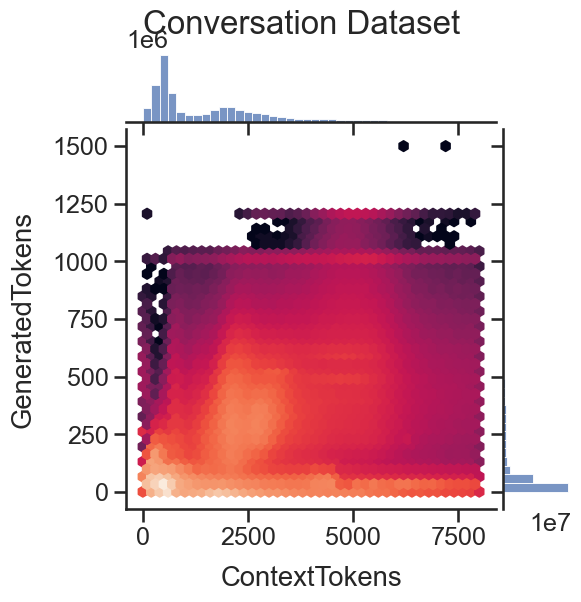

In [120]:
g2 = joint_distribution_plot(
    azure_2024_conv,
    "Conversation Dataset",
    kind="hex_log"
)
plt.show()

#

#

## Azure LMM Inference Trace 2025 (ModServe / SoCC'25, multimodal)
Here we have **multimodal** traffic, it would be interesting to differentiate between the purely text-based interactions and the multimodal ones.

In [108]:
azure_2025_dir = BASE_DIR / "azure_2025"
azure_2025_multimodal = pd.read_csv(azure_2025_dir / "AzureLMMInferenceTrace_multimodal.csv")

azure_2025_multimodal.head()

,TIMESTAMP,NumImages,ContextTokens,GeneratedTokens
0,2024-10-15T12:00:00.269Z,0,770,491
1,2024-10-15T12:00:05.819Z,1,949,126
2,2024-10-15T12:00:06.513Z,1,964,79
3,2024-10-15T12:00:07.332Z,0,78,5
4,2024-10-15T12:00:07.566Z,1,1724,28


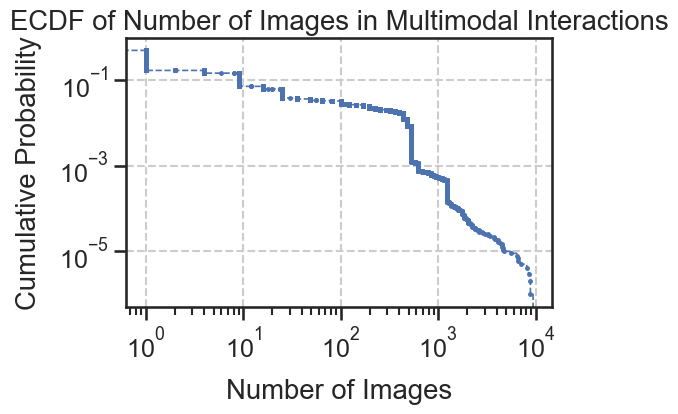

In [133]:
plt.figure(figsize=(5.5, 3.5))
sns.ecdfplot(
    data=azure_2025_multimodal,
    x="NumImages",
    complementary=True
)
plt.xlabel("Number of Images")
plt.ylabel("Cumulative Probability")
plt.title("ECDF of Number of Images in Multimodal Interactions")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()


I do not know how is it possible to have so many interaction with over hundreds of images, what are the use cases here? 

Note: This does not necessarily mean a normal chat user uploaded 120 separate photos by hand. In production, “images” can represent pages of a document, screenshots, extracted frames, batch analysis payloads, or internal service requests that package many visual elements together.

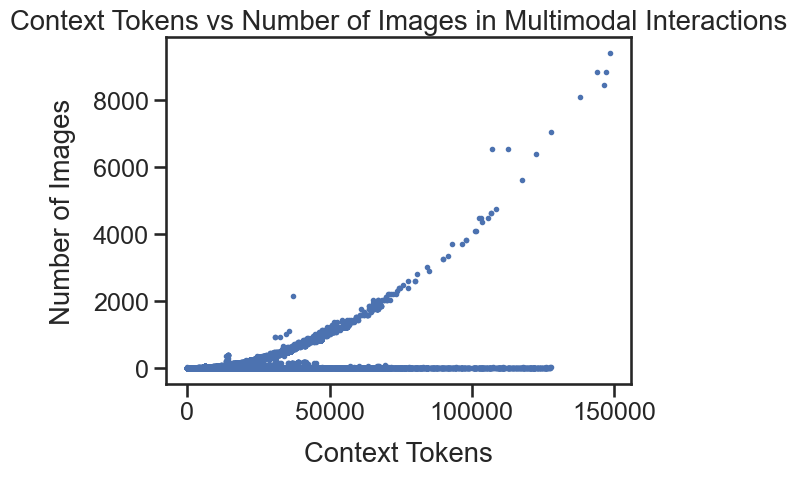

In [126]:
plt.figure(figsize=(6, 4.5))
plt.scatter(azure_2025_multimodal['ContextTokens'], azure_2025_multimodal['NumImages'])
plt.xlabel("Context Tokens")
plt.ylabel("Number of Images")
plt.title("Context Tokens vs Number of Images in Multimodal Interactions")
plt.show()

In [142]:
# show the input and output distribution tokens for the multimodal dataset

def plot_single_ccdf(df1, in_tokens="ContextTokens", out_tokens="GeneratedTokens", loglog=True, title="Multimodal Dataset", ax=None):

    show = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        show = True
    else:           
        fig = ax.figure
    
    sns.ecdfplot(
        data=df1,
        x=in_tokens,
        complementary=True,
        ax=ax,
        label="Input Tokens"
    )
    sns.ecdfplot(
        data=df1,
        x=out_tokens,
        complementary=True,
        ax=ax,
        label="Output Tokens"
    )
    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Number of Input Tokens")
    ax.set_ylabel("CCDF")
    ax.legend()
    ax.grid()
    
    if show:
        plt.tight_layout()
        plt.show()

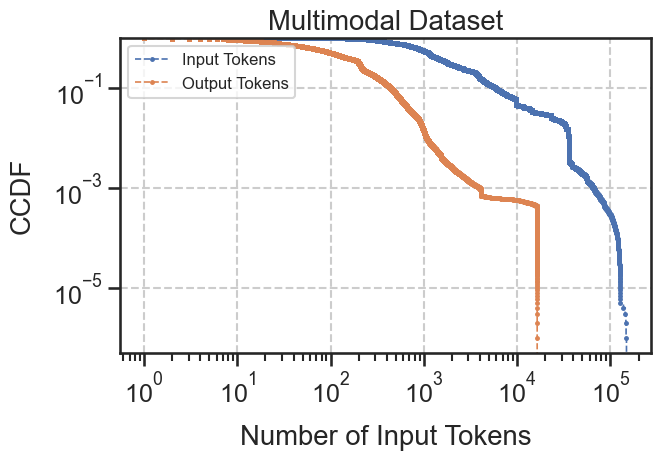

In [137]:
plot_single_ccdf(azure_2025_multimodal, in_tokens="ContextTokens", out_tokens="GeneratedTokens")

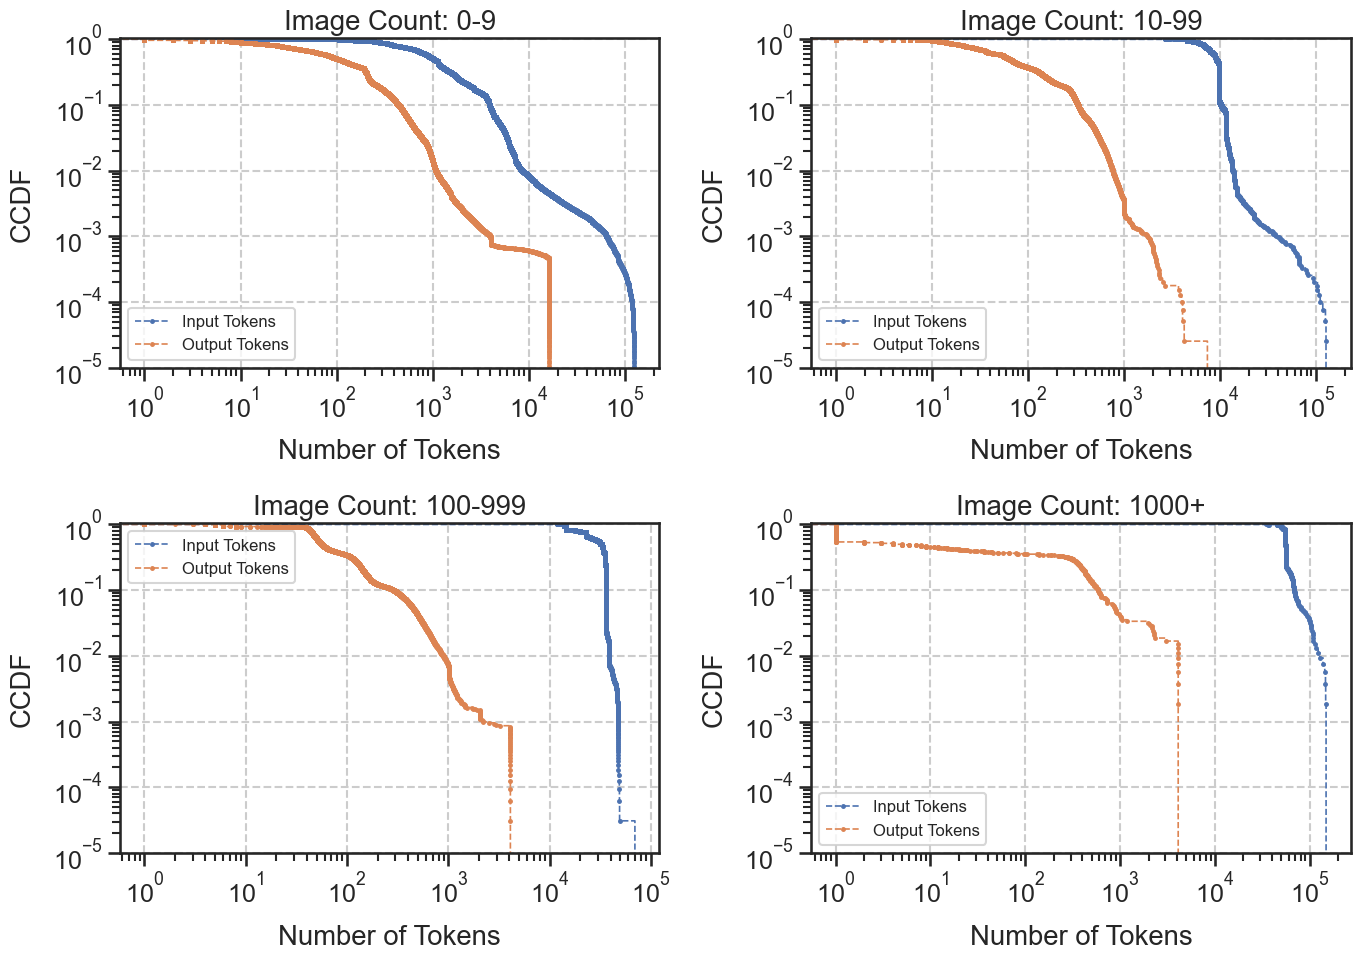

In [147]:
# do the same analysis but considering requests with 0-9, 10-99, 100-999, and 1000+ images separately

azure_2025_multimodal["ImageCountCategory"] = pd.cut(
    azure_2025_multimodal["NumImages"],
    bins=[-1, 9, 99, 999, float("inf")],
    labels=["0-9", "10-99", "100-999", "1000+"]
)

categories = azure_2025_multimodal["ImageCountCategory"].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for cat, ax in zip(categories, axes.flatten()):
    subset = azure_2025_multimodal[azure_2025_multimodal["ImageCountCategory"] == cat]
    plot_single_ccdf(
        subset,
        in_tokens="ContextTokens",
        out_tokens="GeneratedTokens",
        loglog=True,
        title=f"Multimodal Dataset - Image Count: {cat}",
        ax=ax
    )
    ax.set_title(f"Image Count: {cat}")
    ax.set_xlabel("Number of Tokens")
    ax.set_ylabel("CCDF")
    ax.legend()
    ax.grid(True)

    ax.set_ylim(1e-5, 1.05)

plt.tight_layout()
plt.show()

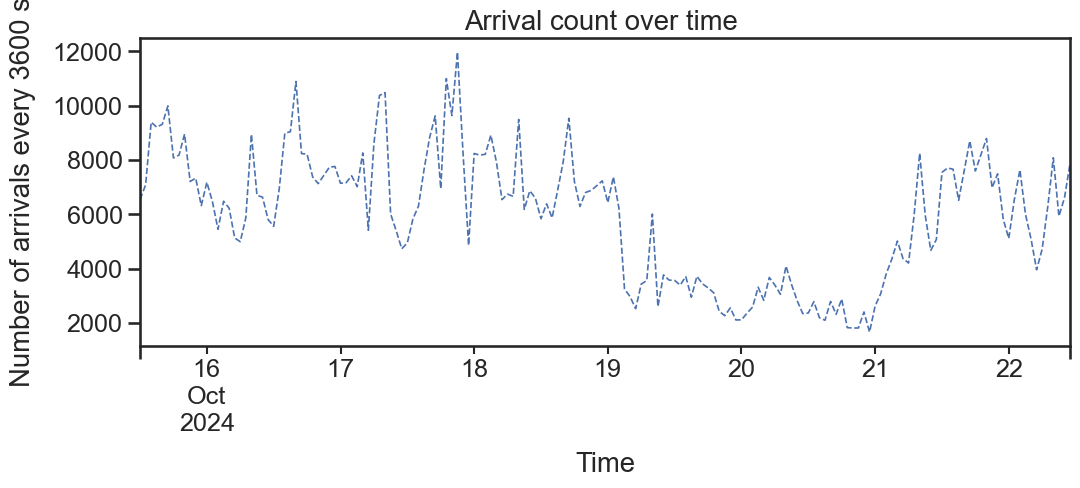

Poisson check for Multimodal Dataset:
Mean count: 5952.380952380952
Variance count: 5584068.009694896
Fano factor: 938.1234256287424


In [149]:
# ------------- Arrivals information -------------

RESAMPLE_SEC = 3600

# arrivals over time
arrival_count_over_time(azure_2025_multimodal, timestamp_col="TIMESTAMP", resample_sec=RESAMPLE_SEC, add_title_suffix="")

# Poisson check
print("Poisson check for Multimodal Dataset:")
poisson_check(azure_2025_multimodal, timestamp_col="TIMESTAMP", window_sec=RESAMPLE_SEC)

#

#

#

## BurstGPT (KDD 2025)

In [192]:
burstgpt_dir = BASE_DIR / "burstgpt"

burstgpt_1 = pd.read_csv(burstgpt_dir / "BurstGPT_1.csv")
burstgpt_2 = pd.read_csv(burstgpt_dir / "BurstGPT_2.csv")

# make an overall dataset (dividing in "conversational" and API calls)
burstgpt_api = pd.concat([
    burstgpt_1[burstgpt_1["Log Type"] == "API log"],
    burstgpt_2[burstgpt_2["Log Type"] == "API log"]
], ignore_index=True)

burstgpt_chat = pd.concat([
    burstgpt_1[burstgpt_1["Log Type"] == "Conversation log"],
    burstgpt_2[burstgpt_2["Log Type"] == "Conversation log"]
], ignore_index=True)

print("\nAPI Calls:")
print(burstgpt_api['Model'].value_counts())
print("\nConversations:")
print(burstgpt_chat['Model'].value_counts())


API Calls:
Model
ChatGPT    4810532
GPT-4       242362
Name: count, dtype: int64

Conversations:
Model
ChatGPT    159736
GPT-4       75543
Name: count, dtype: int64


In [198]:
burstgpt_chat.head()

,Timestamp,Model,Request tokens,Response tokens,Total tokens,Log Type
0,5.0,ChatGPT,472,18,490,Conversation log
1,45.0,ChatGPT,1087,230,1317,Conversation log
2,118.0,GPT-4,417,276,693,Conversation log
3,185.0,ChatGPT,1360,647,2007,Conversation log
4,214.0,ChatGPT,185,215,400,Conversation log


In [197]:
# how is the timestamp saved (fix the above arrivals evaluation if needed)
burstgpt_chat.dtypes

Timestamp          float64
Model                  str
Request tokens       int64
Response tokens      int64
Total tokens         int64
Log Type               str
dtype: object

#

Here we do not have *code* and *conversational* but we have **API** and *conversational*.

C:\Users\localadmin\AppData\Local\Temp\ipykernel_104436\3313154841.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\localadmin\.venvs\llm-vidur\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


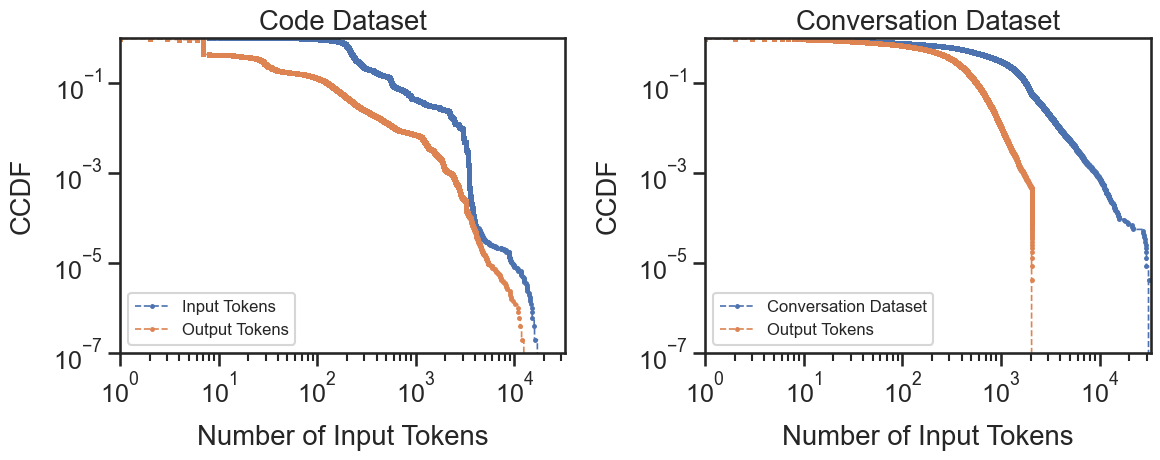

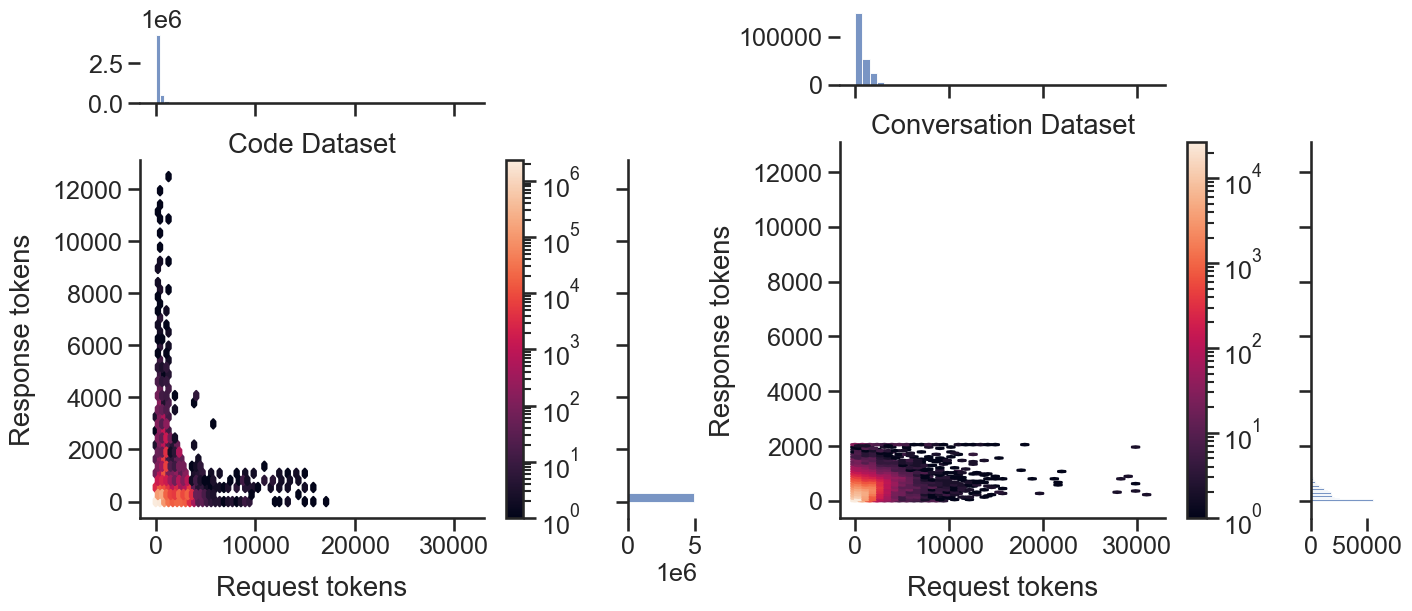

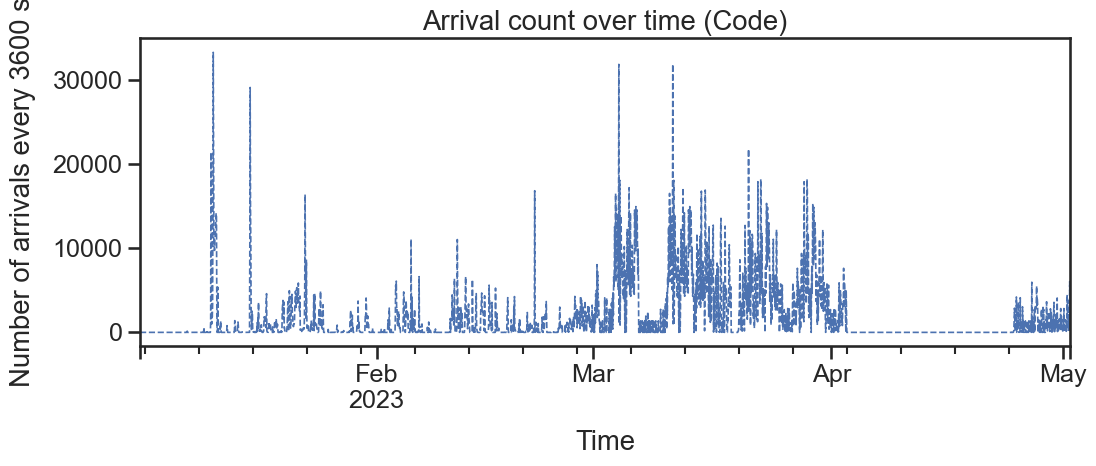

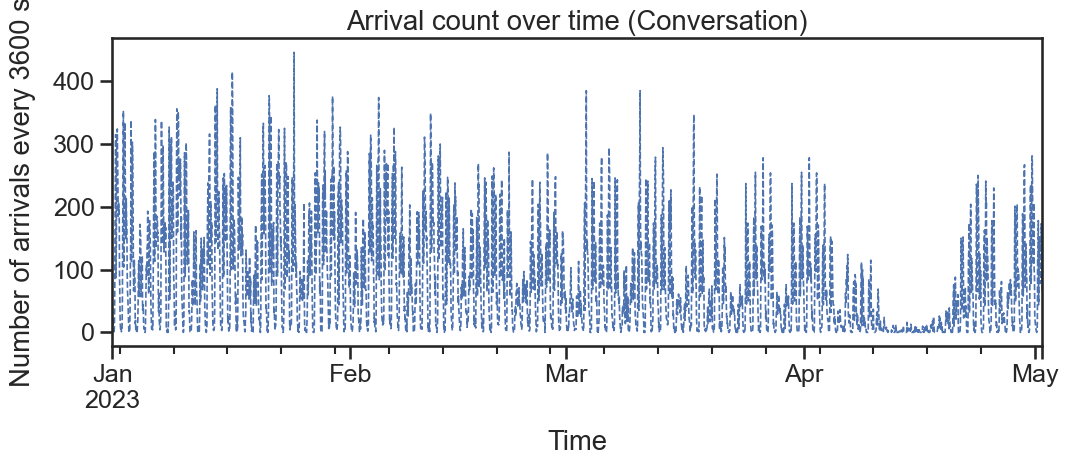

Poisson check for Code Dataset:
Mean count: 1744.181567138419
Variance count: 11432690.81163525
Fano factor: 6554.759565767126

Poisson check for Conversation Dataset:
Mean count: 81.01893939393939
Variance count: 6959.433674933977
Fano factor: 85.8988494171102


In [204]:
all_analysis(burstgpt_api, burstgpt_chat, in_tokens="Request tokens", out_tokens="Response tokens", time_col="Timestamp", joint_kind="hex_log", y_lower=1e-7)

#

#

---

## **Cross-Dataset Comparison**

Side-by-side comparison of **Azure 2023**, **Azure 2024**, **Azure 2025**, and **BurstGPT** on a unified basis. Each dataset's sub-types (code / conversation, API / chat) are shown as separate series so intra- and inter-dataset differences are both visible.

> **Azure 2025 note:** `ContextTokens` includes both text and image tokens — comparisons with text-only datasets should account for this.

In [205]:
# Unified catalog: (label, dataframe, input_col, output_col)
records = [
    ("Azure 2023 Code",       azure_2023_code,       "ContextTokens",  "GeneratedTokens"),
    ("Azure 2023 Conv",       azure_2023_conv,       "ContextTokens",  "GeneratedTokens"),
    ("Azure 2024 Code",       azure_2024_code,       "ContextTokens",  "GeneratedTokens"),
    ("Azure 2024 Conv",       azure_2024_conv,       "ContextTokens",  "GeneratedTokens"),
    ("Azure 2025 Multimodal", azure_2025_multimodal, "ContextTokens",  "GeneratedTokens"),
    ("BurstGPT API",          burstgpt_api,          "Request tokens", "Response tokens"),
    ("BurstGPT Chat",         burstgpt_chat,         "Request tokens", "Response tokens"),
]

### Token Count Statistics

In [211]:
rows = []
for label, df, in_col, out_col in records:
    for metric, s in [("Input tokens", df[in_col]), ("Output tokens", df[out_col])]:
        s = s.dropna()
        rows.append({
            "Dataset": label,
            "Metric":  metric,
            "Mean":    f"{s.mean():.0f}",
            "p50":     f"{s.quantile(0.50):.0f}",
            "p90":     f"{s.quantile(0.90):.0f}",
            "p95":     f"{s.quantile(0.95):.0f}",
            "p99":     f"{s.quantile(0.99):.0f}",
            "Max":     f"{int(s.max())}",
        })

stats_df = pd.DataFrame(rows).set_index(["Dataset", "Metric"])
stats_df

Mean   p50   p90   p95    p99     Max
Dataset               Metric                                              
Azure 2023 Code       Input tokens   2048  1469  5188  7303   7436    7437
                      Output tokens    28    13    55    90    251    1899
Azure 2023 Conv       Input tokens   1155  1020  2734  4083   4142   14050
                      Output tokens   211   129   424   451    601    1000
Azure 2024 Code       Input tokens   2511  1930  6251  7674   7685    7743
                      Output tokens    23     8    43    79    271    5000
Azure 2024 Conv       Input tokens   1632   928  3830  4943   6683    7999
                      Output tokens   106    41   342   455    694    1500
Azure 2025 Multimodal Input tokens   2911  1124  5828  9755  35932  148569
                      Output tokens   187    98   433   603   1066   16384
BurstGPT API          Input tokens    333   216   564   891   2861   17116
                      Output tokens    50     7   125   191    607   12472
BurstGPT Chat         Input tokens    760   483  1775  2159   3883   31407
                      Output tokens   253   201   560   692   1006    2048

#### Same Table but slightly different (prettier) formatting

In [213]:
rows = []

for label, df, in_col, out_col in records:
    for metric, s in [
        ("Input tokens", df[in_col]),
        ("Output tokens", df[out_col])
    ]:
        s = pd.to_numeric(s, errors="coerce").dropna()

        rows.append({
            "Dataset": label,
            "Metric": metric,
            "Mean": s.mean(),
            "p50": s.quantile(0.50),
            "p90": s.quantile(0.90),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "Max": s.max(),
        })

stats_df = pd.DataFrame(rows).set_index(["Dataset", "Metric"])

styled_stats = (
    stats_df.style
    .format({
        "N": "{:,.0f}",
        "Mean": "{:,.0f}",
        "p50": "{:,.0f}",
        "p90": "{:,.0f}",
        "p95": "{:,.0f}",
        "p99": "{:,.0f}",
        "Max": "{:,.0f}",
    })
    .set_caption("Token Count Summary Statistics")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("margin-bottom", "8px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#525252"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "1px solid #999"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "right"),
                ("padding", "6px 10px"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "13px"),
            ],
        },
    ])
)

styled_stats

### Token Count Distributions (CCDF)

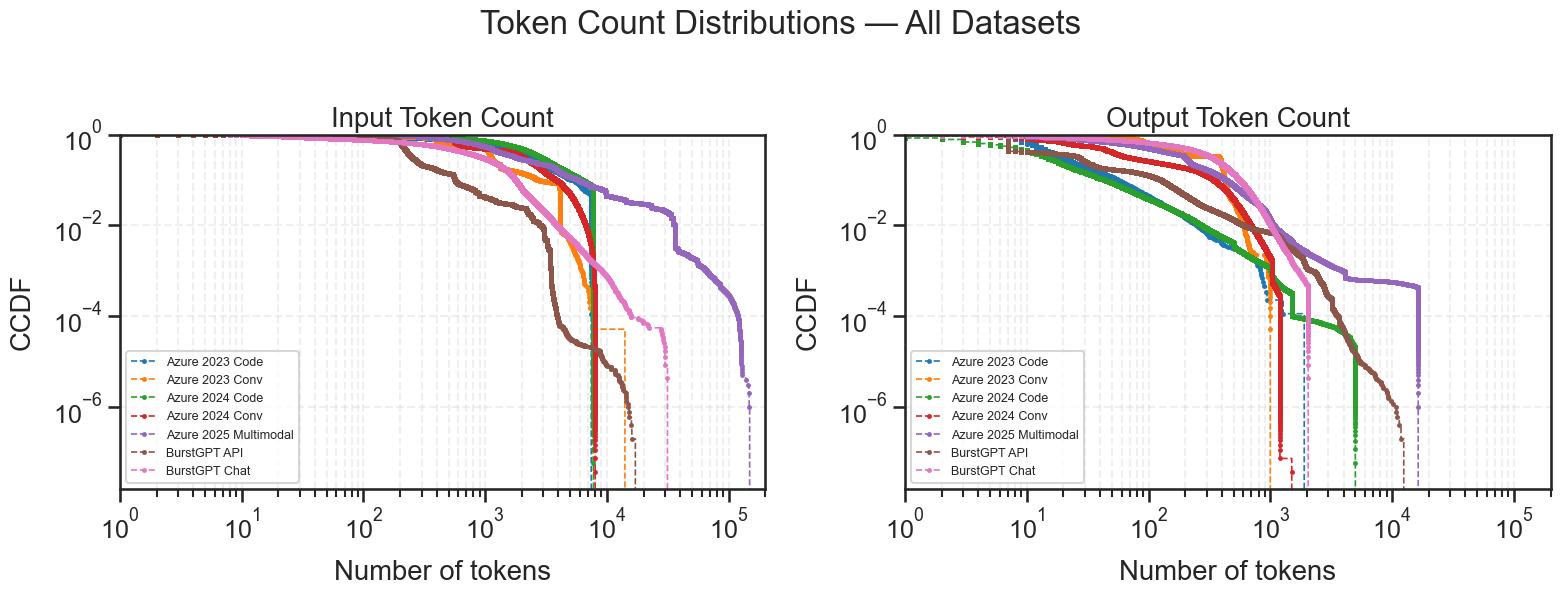

In [219]:
palette = sns.color_palette("tab10", n_colors=len(records))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col_key, title in [
    (axes[0], "in",  "Input Token Count"),
    (axes[1], "out", "Output Token Count"),
]:
    for (label, df, in_col, out_col), color in zip(records, palette):
        col = in_col if col_key == "in" else out_col
        sns.ecdfplot(data=df, x=col, complementary=True, ax=ax, label=label, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of tokens")
    ax.set_ylabel("CCDF")
    ax.set_xlim(1, 2e5)
    ax.set_title(title)
    ax.legend(fontsize=9, loc="lower left")
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Token Count Distributions — All Datasets", y=1.01)
plt.tight_layout()
plt.show()

# execution time ~ 4 min

### Output-to-Input Token Ratio

The ratio `output tokens / input tokens` measures how decode-heavy a workload is. Values below 1 (the vast majority in production) indicate prefill-heavy traffic — large contexts with short answers. Values above 1 indicate long generative outputs relative to the prompt.

In [208]:
ratio_rows = []
for label, df, in_col, out_col in records:
    r = (df[out_col] / df[in_col]).dropna()
    ratio_rows.append({
        "Dataset": label,
        "Mean":    f"{r.mean():.3f}",
        "p50":     f"{r.quantile(0.50):.3f}",
        "p75":     f"{r.quantile(0.75):.3f}",
        "p90":     f"{r.quantile(0.90):.3f}",
        "p95":     f"{r.quantile(0.95):.3f}",
        "p99":     f"{r.quantile(0.99):.3f}",
    })

ratio_df = pd.DataFrame(ratio_rows).set_index("Dataset")
ratio_df

,Mean,p50,p75,p90,p95,p99
Dataset,,,,,,
Azure 2023 Code,0.090,0.011,0.040,0.143,0.303,1.156
Azure 2023 Conv,0.430,0.279,0.393,0.592,0.947,4.982
Azure 2024 Code,0.067,0.004,0.015,0.058,0.138,0.773
Azure 2024 Conv,0.104,0.048,0.130,0.224,0.349,0.739
Azure 2025 Multimodal,inf,0.082,0.219,0.500,0.696,2.246
BurstGPT API,0.153,0.035,0.159,0.339,0.660,1.453
BurstGPT Chat,1.991,0.313,0.881,5.609,12.333,26.102


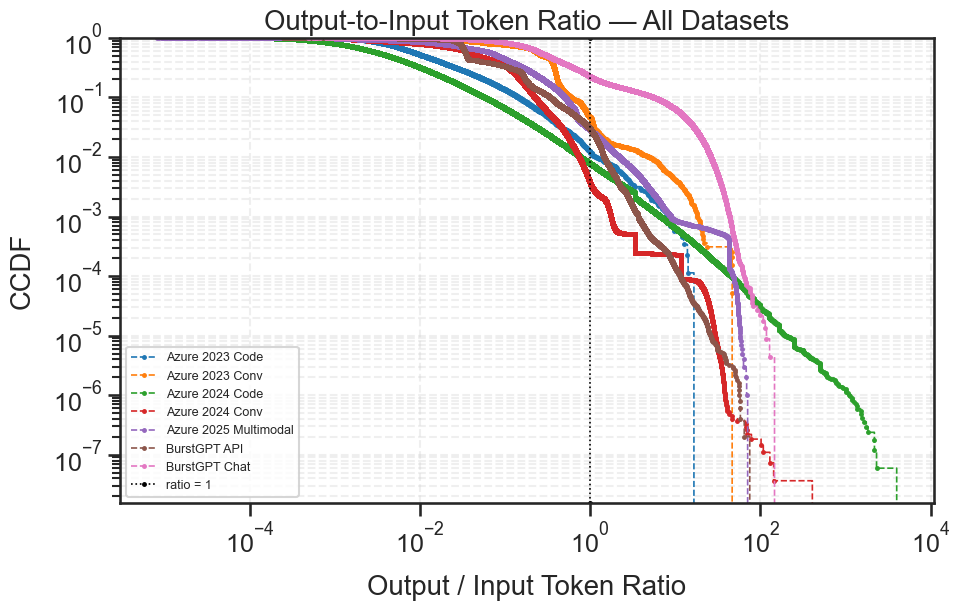

In [217]:
fig, ax = plt.subplots(figsize=(10, 6.5))
palette = sns.color_palette("tab10", n_colors=len(records))

for (label, df, in_col, out_col), color in zip(records, palette):
    r = (df[out_col] / df[in_col]).dropna()
    sns.ecdfplot(x=r, complementary=True, ax=ax, label=label, color=color)

ax.axvline(1.0, color="black", linestyle=":", linewidth=1.2, label="ratio = 1")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Output / Input Token Ratio")
ax.set_ylabel("CCDF")
ax.set_title("Output-to-Input Token Ratio — All Datasets")
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# execution time ~ 1 min